# 散佈圖 Scatter Plot：看懂「兩件事有沒有一起改變」

住得越遠，上課就一定越容易遲到嗎？外送距離近，為什麼還是等很久？飲料越貴真的越滿意嗎？找房子時，坪數越大就一定越貴？

這些問題的共同點是：我們不只想知道「誰比較多」，而是想比較**同一個對象的兩個數值**。散佈圖把每次通勤、每筆訂單或每個物件放成一個點，讓我們看見方向、分組、重疊與例外。

## 第一部分｜Matplotlib

### 先把散佈圖想成貼在方格紙上的便條

小安家到教室 3 公里，今天通勤 20 分鐘。把這筆資料寫成 `(3, 20)`：先沿橫軸走到 3，再沿縱軸往上找到 20，貼一個點。另一位同學 5 公里、23 分鐘，再貼一個點。每個點必須來自同一筆紀錄的兩個欄位，不能把甲的距離配到乙的時間。

| 元素 | 生活理解 | 每次畫圖都要問 |
|---|---|---|
| 一個點 | 一張配好 x、y 的紀錄卡 | 是一人、一單、一日，還是一個平均？ |
| x 軸 | 左右位置，例如公里 | 單位、資料範圍與意義是什麼？ |
| y 軸 | 上下位置，例如分鐘 | 高一點代表多多少？ |
| 顏色 | 可表示類別或第三個數值 | 需要圖例還是色條？ |
| 大小 | 可再表示一個數值 | 是面積，不是半徑；有沒有對照？ |

散佈圖通常**不把點連起來**。租屋物件沒有先後路線，任意連線會讓讀者以為它們沿某條路徑變化。若問題是「每天怎麼變」，時間折線圖可能更適合；若問題是「哪個品項總共賣最多」，長條圖更直接。

### 不需要先背公式，也能開始讀圖

先依序看：**方向、形狀、分散程度、分組、例外**。

- 點大致往右上：x 較大時 y 常也較大，稱正向關聯。
- 點大致往右下：x 較大時 y 常較小，稱負向關聯。
- 同樣 x 附近有很大高低差：還有其他因素，不能只用 x 決定 y。
- 點分成幾團：可能來自不同交通方式、地區或時段。
- 少數點遠離其他點：值得核對，但不代表一定是錯誤。

「距離長的同學通常通勤較久」是觀察；「搬遠一公里就一定多花五分鐘」則是更強的因果／預測說法，單憑圖還不夠。不同人、交通方式、等車時間都可能影響結果。把變數放在 x 軸，不會讓它自動變成原因。

### 範例：第一張通勤散佈圖

先用六位虛構同學的通勤紀錄，回答「住得越遠是否通常花更久？」資料直接寫在程式裡，不需讀檔。


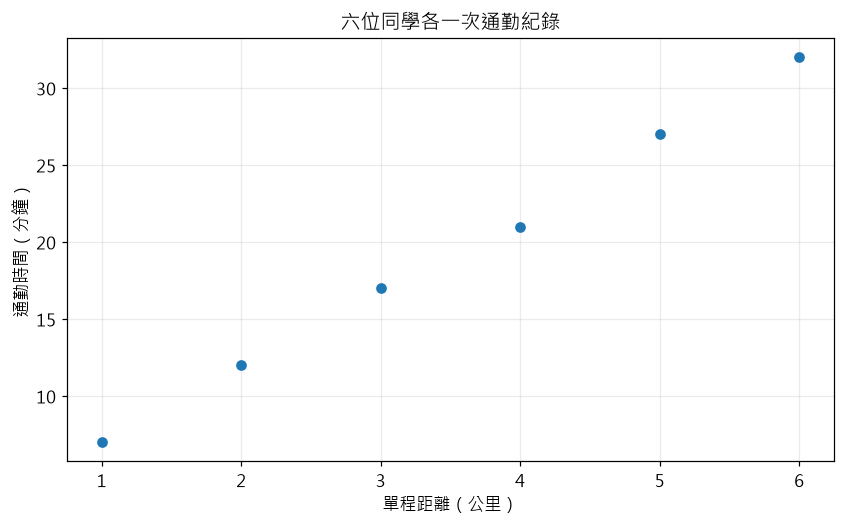

紀錄筆數： 6


In [ ]:
distance = [1, 2, 3, 4, 5, 6]
minutes = [7, 12, 17, 21, 27, 32]

import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 4))
	ax.scatter(distance, minutes)
	ax.set(title="六位同學各一次通勤紀錄", xlabel="單程距離（公里）", ylabel="通勤時間（分鐘）")
	ax.grid(alpha=0.25)
	ax.set_axisbelow(True)
	plt.show()

### 範例：CSV讀取與座標配對

Matplotlib 範例檔："./Scatter_Plot_data/同學通勤距離時間.csv"

18 位不同同學，交通方式也不同。示範為什麼不能單獨排序其中一欄。


In [5]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/同學通勤距離時間.csv", encoding="utf-8-sig")
df.head()

,同學編號,方式,距離公里,通勤分鐘
0,S01,公車,2,18
1,S02,公車,3,25
2,S03,公車,4,23
3,S04,公車,5,32
4,S05,公車,7,40


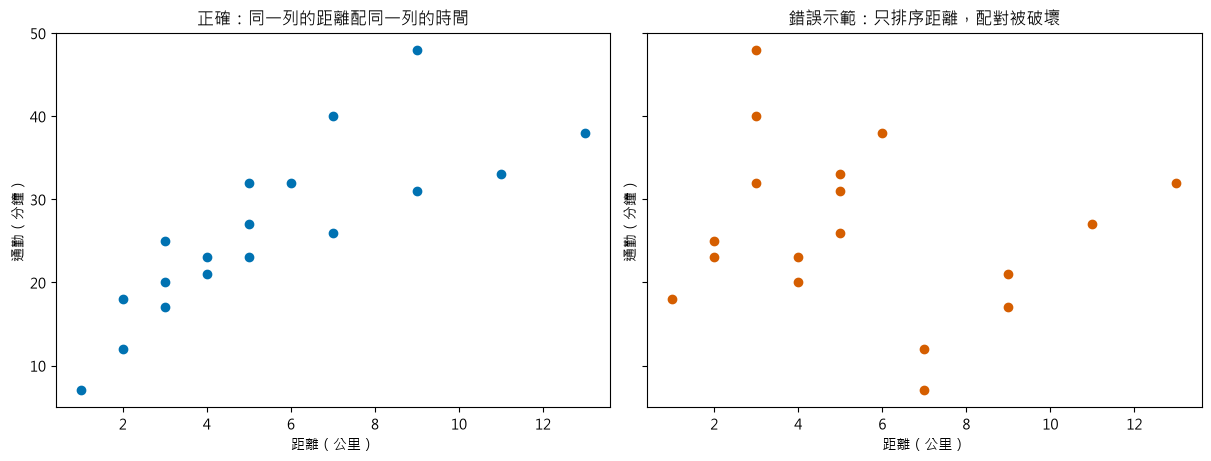

In [7]:
import matplotlib.pyplot as plt
import numpy as np

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	
	fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True, layout="constrained")
	axes[0].scatter(df["距離公里"], df["通勤分鐘"], color="#0072B2")
	axes[0].set_title("正確：同一列的距離配同一列的時間")
	axes[1].scatter(np.sort(df["距離公里"].to_numpy()), df["通勤分鐘"], color="#D55E00")
	axes[1].set_title("錯誤示範：只排序距離，配對被破壞")
	for ax in axes:
		ax.set(xlabel="距離（公里）", ylabel="通勤（分鐘）")
	plt.show()


### 範例：標記大小透明度與邊框

Matplotlib 範例檔："./Scatter_Plot_data/外送訂單觀察.csv"

36 筆訂單，先只看距離與等待，不急著塞進所有欄位。


In [9]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/外送訂單觀察.csv", encoding="utf-8-sig")
df.head()

,訂單編號,天氣,時段,距離公里,等待分鐘,餐點份數,付款金額
0,D01,晴天,下午離峰,0.8,16,1,135
1,D02,晴天,午餐尖峰,1.5,24,4,435
2,D03,晴天,下午離峰,2.2,24,2,235
3,D04,晴天,午餐尖峰,2.9,32,5,535
4,D05,晴天,下午離峰,3.6,27,3,335


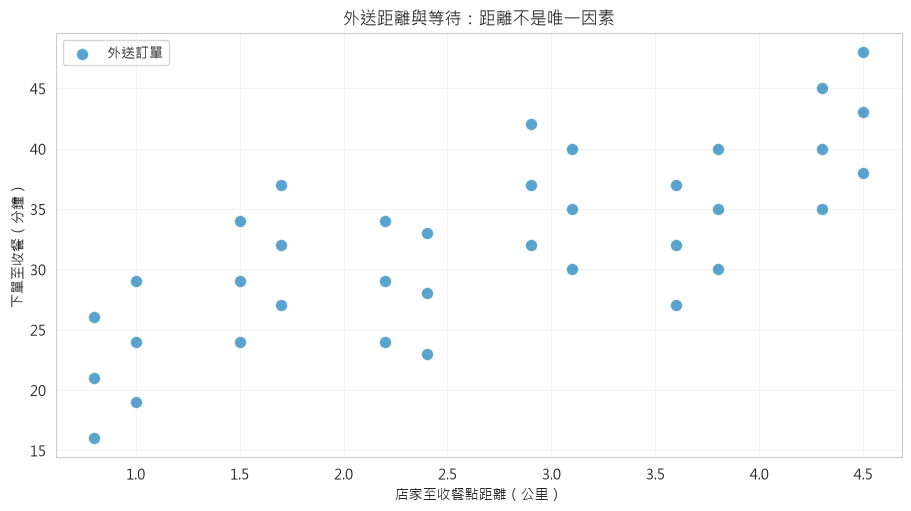

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
	ax.scatter(df["距離公里"], df["等待分鐘"], s=75, color="#0072B2",
			marker="o", alpha=0.65, edgecolors="white", linewidths=0.7, label="外送訂單")
	ax.set(title="外送距離與等待：距離不是唯一因素", xlabel="店家至收餐點距離（公里）", ylabel="下單至收餐（分鐘）")
	ax.grid(alpha=0.2)
	ax.set_axisbelow(True)
	ax.legend()
	plt.show()


### 範例：屋齡連續色階與色條

Matplotlib 範例檔："./Scatter_Plot_data/租屋物件條件.csv"

想在坪數、月租之外再查看屋齡，使用有數值順序的連續色階。


In [16]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/租屋物件條件.csv", encoding="utf-8-sig")
df.head()

,物件編號,地區,室內坪數,月租,屋齡
0,R01,市中心,10,18000,5
1,R02,市中心,12,19300,18
2,R03,市中心,14,20200,10
3,R04,市中心,16,21600,25
4,R05,市中心,18,22400,8


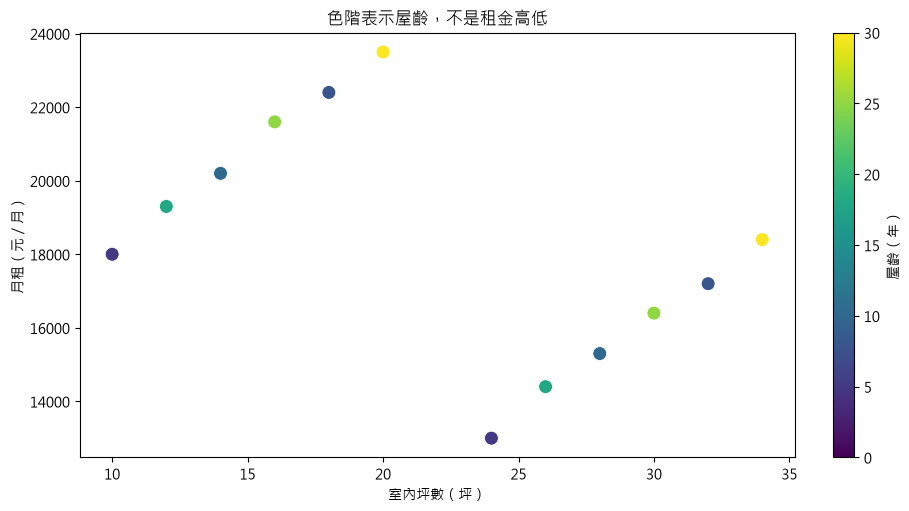

In [17]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
	points = ax.scatter(df["室內坪數"], df["月租"], c=df["屋齡"], cmap="viridis",
						vmin=0, vmax=30, s=100, edgecolors="white", linewidths=0.6)
	colorbar = fig.colorbar(points, ax=ax)
	colorbar.set_label("屋齡（年）")
	ax.set(title="色階表示屋齡，不是租金高低", xlabel="室內坪數（坪）", ylabel="月租（元／月）")
	plt.show()

### 範例：外送餐點份數的泡泡圖

Matplotlib 範例檔：""./Scatter_Plot_data/外送訂單觀察.csv

每點仍是一張訂單，用面積表示幾份餐點，練習第三個數值的編碼。


In [21]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/外送訂單觀察.csv", encoding="utf-8-sig")
df.head()

,訂單編號,天氣,時段,距離公里,等待分鐘,餐點份數,付款金額
0,D01,晴天,下午離峰,0.8,16,1,135
1,D02,晴天,午餐尖峰,1.5,24,4,435
2,D03,晴天,下午離峰,2.2,24,2,235
3,D04,晴天,午餐尖峰,2.9,32,5,535
4,D05,晴天,下午離峰,3.6,27,3,335


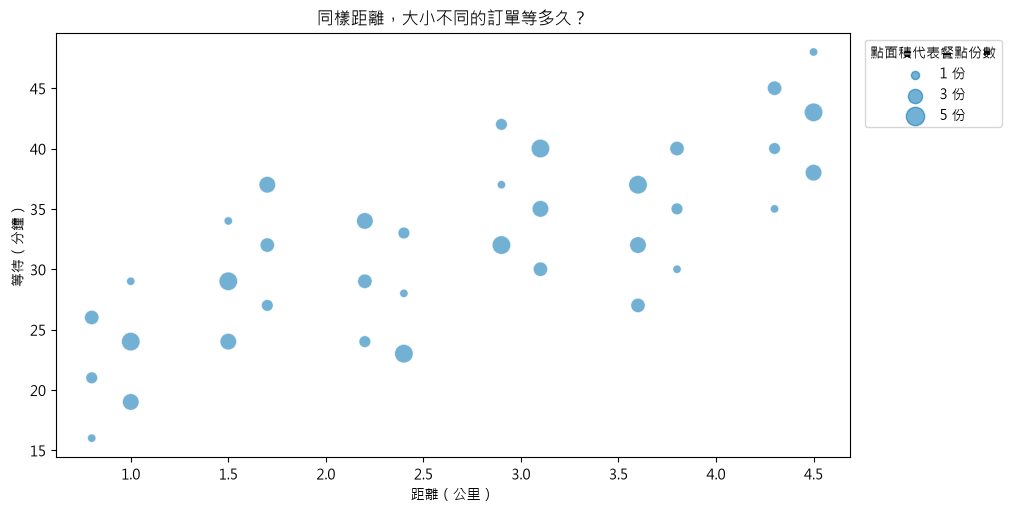

In [23]:
import matplotlib.pyplot as plt

area_per_portion = 35

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
	ax.scatter(df["距離公里"], df["等待分鐘"], s=df["餐點份數"] * area_per_portion,
			color="#0072B2", alpha=0.55, edgecolors="white", linewidths=0.5)
	for portions in [1, 3, 5]:
		ax.scatter([], [], s=portions * area_per_portion, color="#0072B2", alpha=0.55, label=f"{portions} 份")
	ax.legend(title="點面積代表餐點份數", loc="upper left", bbox_to_anchor=(1.01, 1))
	ax.set(title="同樣距離，大小不同的訂單等多久？", xlabel="距離（公里）", ylabel="等待（分鐘）")
	plt.show()

### 範例 08｜預估與實際通勤的對角線

Matplotlib 範例檔："./Scatter_Plot_data/預估與實際通勤.csv"


[08_預估與實際通勤的對角線.py](./examples/08_預估與實際通勤的對角線.py)

出門前預估與到達後實際時間放在同一圖，找常低估還是高估。


In [25]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/預估與實際通勤.csv", encoding="utf-8-sig")
df["實際減預估"] = df["實際分鐘"] - df["預估分鐘"]
df

,紀錄編號,預估分鐘,實際分鐘,實際減預估
0,E01,15,18,3
1,E02,20,20,0
2,E03,25,22,-3
3,E04,30,38,8
4,E05,35,40,5
5,E06,40,37,-3
6,E07,45,52,7
7,E08,50,55,5
8,E09,55,53,-2
9,E10,60,72,12


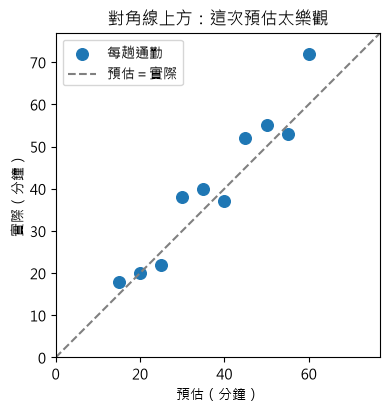

In [28]:
import matplotlib.pyplot as plt

limit = max(df["預估分鐘"].max(), df["實際分鐘"].max()) + 5

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
	ax.scatter(df["預估分鐘"], df["實際分鐘"], s=70, label="每趟通勤")
	ax.plot([0, limit], [0, limit], color="gray", linestyle="--", label="預估＝實際")
	ax.set(xlim=(0, limit), ylim=(0, limit), xlabel="預估（分鐘）", ylabel="實際（分鐘）", title="對角線上方：這次預估太樂觀")
	ax.set_aspect("equal", adjustable="box")
	ax.legend()
	plt.show()

## 從這邊開始

### 範例：Matplotlib午餐條件篩選報告

範例檔："./Scatter_Plot_data/午餐選擇情境.csv"

現在只有 20 分鐘且預算 120 元，哪些方案符合？這是篩選練習，還不是替每個人決定吃什麼。


In [29]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/午餐選擇情境.csv", encoding="utf-8-sig")
df

,選項,方式,費用,取得分鐘
0,A雞肉便當,自備,60,35
1,B蔬菜麵,自備,50,25
2,C前晚便當,自備,55,12
3,D飯糰豆漿,店內購買,75,10
4,E排骨便當,店內購買,110,18
5,F牛肉麵,店內購買,160,22
6,G雞腿飯,店內購買,125,15
7,H自助餐,店內購買,100,14
8,I外送便當,外送,145,32
9,J外送義麵,外送,210,45


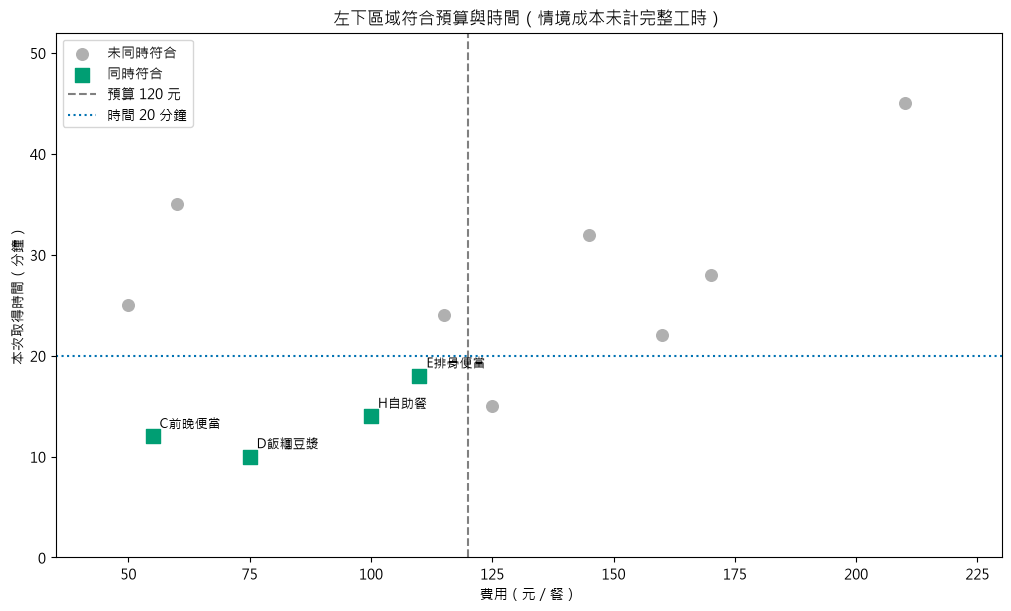

In [32]:
import matplotlib.pyplot as plt

### 設定預算與時間限制
budget, time_limit = 120, 20
### 判斷是否同時符合預算與時間限制
fits = (df["費用"] <= budget) & (df["取得分鐘"] <= time_limit)

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
	ax.scatter(df.loc[~fits, "費用"], df.loc[~fits, "取得分鐘"], s=70, color="#B0B0B0", label="未同時符合")
	ax.scatter(df.loc[fits, "費用"], df.loc[fits, "取得分鐘"], s=95, color="#009E73", marker="s", label="同時符合")
	ax.axvline(budget, color="gray", linestyle="--", label="預算 120 元")
	ax.axhline(time_limit, color="#0072B2", linestyle=":", label="時間 20 分鐘")
	for _, row in df.loc[fits].iterrows():
		ax.annotate(row["選項"], (row["費用"], row["取得分鐘"]), xytext=(5, 6), textcoords="offset points", fontsize=9)
	ax.set(title="左下區域符合預算與時間（情境成本未計完整工時）", xlabel="費用（元／餐）", ylabel="本次取得時間（分鐘）", xlim=(35, 230), ylim=(0, 52))
	ax.legend(loc="upper left")
	plt.show()

## 第二部分：使用 Seaborn 

Seaborn 也是用 Matplotlib 畫圖，但可以直接指定表格欄名，自動幫我們處理顏色、形狀、大小與圖例。常見合作方式是 `fig, ax = plt.subplots()` 建座標，`sns.scatterplot(..., ax=ax)` 畫點，`ax.set()` 設定標題。

**和前面學過的長條圖、折線圖預設不同：`sns.scatterplot()` 的基本用法是畫個別觀測，不會自動把同一 x 的 y 求平均，也不會自動加迴歸線。** 相同座標仍可能疊在一起，並不代表那裡只有一筆。

| 參數 | 白話用途 | 課堂上要能解釋 |
|---|---|---|
| `data` | 用哪張表 | 每列代表什麼 |
| `x`, `y` | 哪兩欄決定位置 | 欄名、單位與配對 |
| `hue` | 用一欄控制顏色 | 類別和連續數字的映射不同 |
| `style` | 用一欄控制形狀 | 通常用少數類別，別塞太多形狀 |
| `size`, `sizes` | 哪一欄控制大小、大小範圍 | 視覺面積不一定直接正比原數值 |
| `hue_order` | 類別圖例順序 | 跨圖保持同樣順序 |
| `hue_norm`, `size_norm` | 數字對應範圍 | 篩選後是否仍可比較 |
| `legend` | 圖例顯示方式 | 摘要刻度不一定是實際出現過的值 |
| `ax` | 放到哪個座標區 | scatterplot 使用；relplot 自己建整張圖 |

先用同一份通勤資料對照，再增加分組。不是每張圖都要同時用 hue、style、size；每加一個設定，讀者就多一件要理解的事。


### 範例：Seaborn第一張通勤散佈圖

範例檔："./Scatter_Plot_data/同學通勤距離時間.csv"

和 Matplotlib 畫同一批點，先確認兩種寫法都保留每筆觀測。


In [33]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/同學通勤距離時間.csv", encoding="utf-8-sig")
df

,同學編號,方式,距離公里,通勤分鐘
0,S01,公車,2,18
1,S02,公車,3,25
2,S03,公車,4,23
3,S04,公車,5,32
4,S05,公車,7,40
5,S06,公車,9,48
6,S07,捷運,3,20
7,S08,捷運,5,23
8,S09,捷運,7,26
9,S10,捷運,9,31


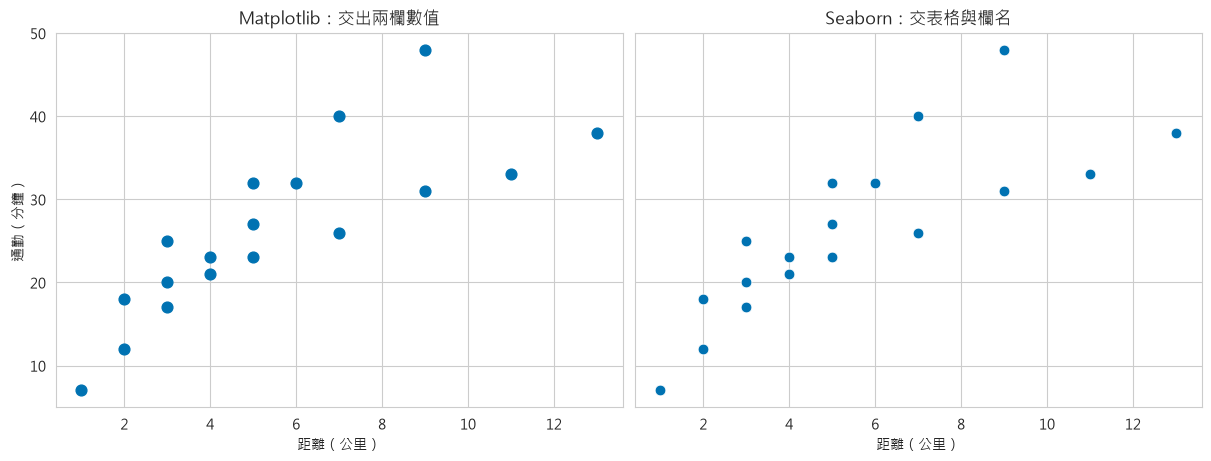

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True, layout="constrained")
	axes[0].scatter(df["距離公里"], df["通勤分鐘"], s=60, color="#0072B2")
	sns.scatterplot(data=df, x="距離公里", y="通勤分鐘", s=60, color="#0072B2", ax=axes[1])
	axes[0].set_title("Matplotlib：交出兩欄數值")
	axes[1].set_title("Seaborn：交表格與欄名")
	for ax in axes:
		ax.set(xlabel="距離（公里）", ylabel="通勤（分鐘）")
	plt.show()

### 範例：交通方式的hue與style

範例檔："./Scatter_Plot_data/同學通勤距離時間.csv"

用更短的分組寫法保留交通方式，讓學生直接對照第一部分迴圈。


In [35]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/同學通勤距離時間.csv", encoding="utf-8-sig")
df

,同學編號,方式,距離公里,通勤分鐘
0,S01,公車,2,18
1,S02,公車,3,25
2,S03,公車,4,23
3,S04,公車,5,32
4,S05,公車,7,40
5,S06,公車,9,48
6,S07,捷運,3,20
7,S08,捷運,5,23
8,S09,捷運,7,26
9,S10,捷運,9,31


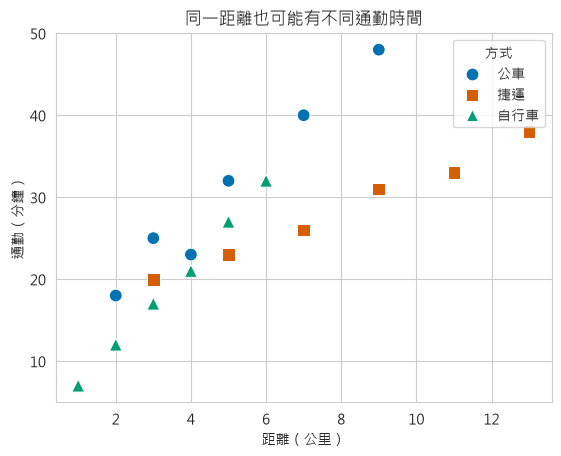

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["公車", "捷運", "自行車"]
palette = {"公車": "#0072B2", "捷運": "#D55E00", "自行車": "#009E73"}
markers = {"公車": "o", "捷運": "s", "自行車": "^"}

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots()
	sns.scatterplot(data=df, x="距離公里", y="通勤分鐘", hue="方式", style="方式",
					hue_order=order, style_order=order, palette=palette, markers=markers, s=85, ax=ax)
	ax.set(title="同一距離也可能有不同通勤時間", xlabel="距離（公里）", ylabel="通勤（分鐘）")
	plt.show()


### 範例：訂單份數的size映射與圖例

範例檔："./Scatter_Plot_data/外送訂單觀察.csv"

顏色辨識天氣，大小辨識餐點份數，說明 Seaborn 對 size 的縮放和 Matplotlib 直接指定 s 的差異。


In [40]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/外送訂單觀察.csv", encoding="utf-8-sig")
df.head()

,訂單編號,天氣,時段,距離公里,等待分鐘,餐點份數,付款金額
0,D01,晴天,下午離峰,0.8,16,1,135
1,D02,晴天,午餐尖峰,1.5,24,4,435
2,D03,晴天,下午離峰,2.2,24,2,235
3,D04,晴天,午餐尖峰,2.9,32,5,535
4,D05,晴天,下午離峰,3.6,27,3,335


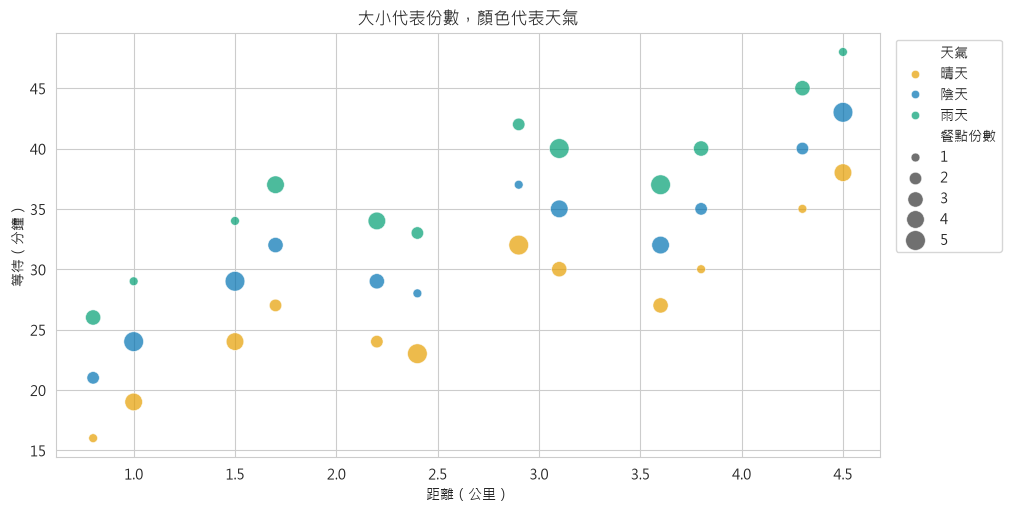

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
	sns.scatterplot(data=df, x="距離公里", y="等待分鐘", hue="天氣", hue_order=["晴天", "陰天", "雨天"],
					palette={"晴天": "#E69F00", "陰天": "#0072B2", "雨天": "#009E73"},
					size="餐點份數", sizes=(40, 200), size_norm=(1, 5), alpha=0.7, legend="full", ax=ax)
	ax.set(title="大小代表份數，顏色代表天氣", xlabel="距離（公里）", ylabel="等待（分鐘）")
	sns.move_legend(ax, "upper left", bbox_to_anchor=(1.01, 1))
	plt.show()


### 範例：連續hue與一致的屋齡色條

範例檔："./Scatter_Plot_data/租屋物件條件.csv"

Seaborn 可以按連續數值上色，但若希望用色條閱讀，要讓色條和散佈點共享同一映射。


In [42]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/租屋物件條件.csv", encoding="utf-8-sig")
df

,物件編號,地區,室內坪數,月租,屋齡
0,R01,市中心,10,18000,5
1,R02,市中心,12,19300,18
2,R03,市中心,14,20200,10
3,R04,市中心,16,21600,25
4,R05,市中心,18,22400,8
5,R06,市中心,20,23500,30
6,R07,近郊,24,13000,5
7,R08,近郊,26,14400,18
8,R09,近郊,28,15300,10
9,R10,近郊,30,16400,25


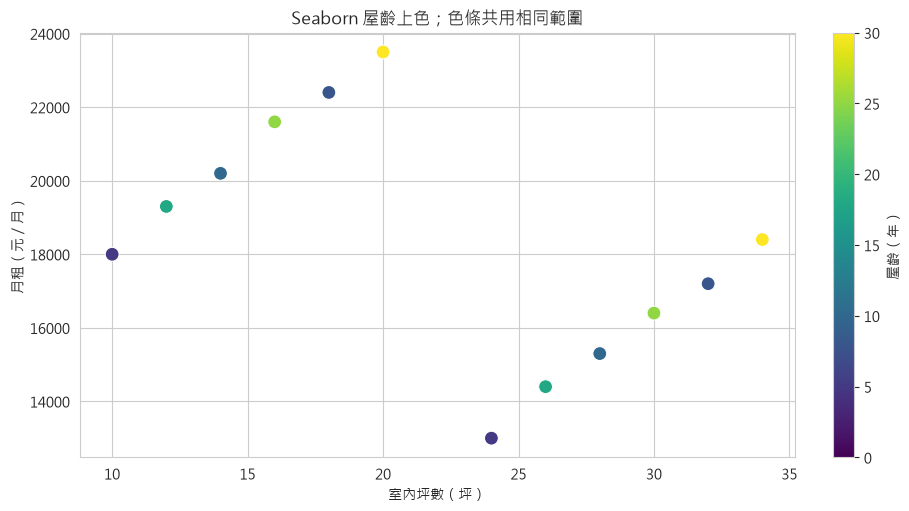

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
from matplotlib.cm import ScalarMappable

norm = colors.Normalize(vmin=0, vmax=30)
cmap = plt.get_cmap("viridis")

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
	sns.scatterplot(data=df, x="室內坪數", y="月租", hue="屋齡", palette=cmap,
					hue_norm=norm, legend=False, s=100, ax=ax)
	mapping = ScalarMappable(norm=norm, cmap=cmap)
	fig.colorbar(mapping, ax=ax, label="屋齡（年）")
	ax.set(title="Seaborn 屋齡上色；色條共用相同範圍", xlabel="室內坪數（坪）", ylabel="月租（元／月）")
	plt.show()


### 趨勢線之前：先認識斜率、殘差與相關

**斜率**是 x 多一單位，線上的 y 增加多少。假設某條示意線是 `等待 = 10 + 4 × 公里`，斜率 4 的單位是分鐘／公里；10 是截距，表示線在 x=0 的高度。但資料若從 1 公里才開始，截距只是數學延伸，不表示真的量過零公里外送。

**殘差**是觀測 y 減去線上估計值。若線在 3 公里估計 22 分鐘，實際等 30 分鐘，殘差為 +8。普通最小平方法找一條讓這些「垂直差距的平方和」盡量小的直線。平方讓正負不抵銷，也讓很大的差距更有影響，因此離群值值得特別檢查。

**Pearson 相關係數 r** 在 −1 到 +1 之間，描述線性關係的方向與緊密程度，沒有公里或分鐘單位。可先想成：把兩欄各自減掉平均，看看偏高、偏低是不是常一起出現，再用各自的變動幅度標準化。

- r 接近 +1：這批點接近向右上的直線。
- r 接近 −1：這批點接近向右下的直線。
- r 接近 0：沒有明顯的整體線性方向，**不代表不存在彎曲關係**。
- 某欄完全不變時，r 可能無法定義；缺值處理也會影響使用了哪些配對。

r 不是斜率，r=0.8 不是「x 解釋了 80% 原因」，也不是「80% 的人符合」。兩個欄位各自變更單位，例如公里改公尺，斜率的數字會變，Pearson r 在正比例換算下不變。

### 三種容易說過頭的話

| 說法 | 問題 | 可以怎麼改 |
|---|---|---|
| 氣溫高所以冰飲一定賣更多 | 未排除假日、促銷、客流 | 這批日紀錄中，較高氣溫常伴隨較高銷量 |
| 線畫到 50 度，所以能預測 50 度銷量 | 超出觀測範圍，屬外推 | 先限制在觀測範圍，收集新條件資料 |
| 點在趨勢線外，所以是錯誤 | 趨勢線本來不是每點都符合 | 先核對原始紀錄，再查可能差異 |

接下來四例是判讀練習：直線摘要、離群影響、非線性、分組混合。比「能不能加一條線」更重要的是「加了以後怎麼解釋」。


### 範例：氣溫與冰飲的線性趨勢


範例檔："./Scatter_Plot_data/氣溫與冰飲銷量.csv"

同店 15 日觀測，先看資料，再用一條直線作摘要；這不是銷售保證。


In [46]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/氣溫與冰飲銷量.csv", encoding="utf-8-sig")
df.head()

,觀測編號,氣溫,冰飲杯數,備註
0,I01,20,28,單店每日一筆
1,I02,21,27,單店每日一筆
2,I03,22,43,單店每日一筆
3,I04,23,41,單店每日一筆
4,I05,24,50,單店每日一筆


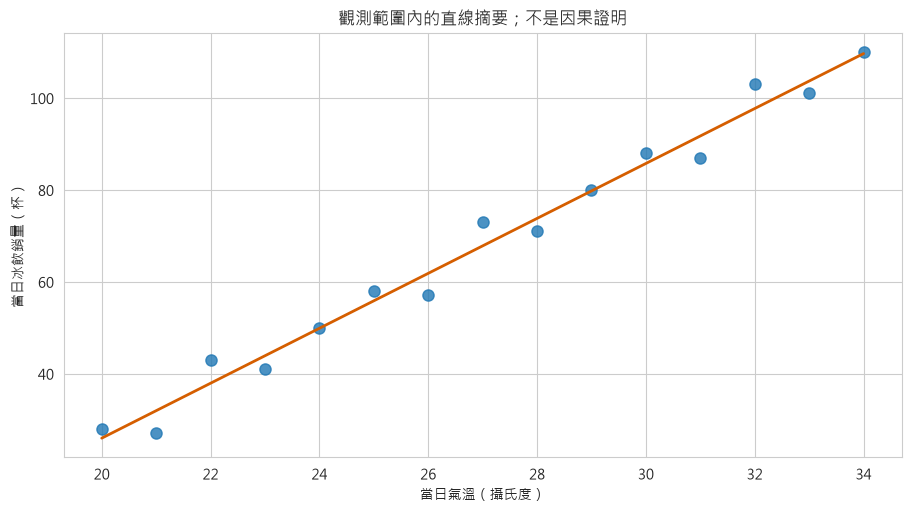

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
	sns.regplot(data=df, x="氣溫", y="冰飲杯數", ci=None, truncate=True,
				scatter_kws={"s": 65, "alpha": 0.8}, line_kws={"color": "#D55E00", "linewidth": 2}, ax=ax)
	ax.set(title="觀測範圍內的直線摘要；不是因果證明", xlabel="當日氣溫（攝氏度）", ylabel="當日冰飲銷量（杯）")
	plt.show()


In [48]:
slope, intercept = np.polyfit(df["氣溫"], df["冰飲杯數"], 1)
r = df["氣溫"].corr(df["冰飲杯數"])
print(f"直線摘要：杯數約為 {intercept:.2f} + {slope:.2f} × 氣溫；r={r:.3f}")
print("單店跨日觀測可能相依；此例未建立抽樣推論或因果模型。")

直線摘要：杯數約為 -93.62 + 5.98 × 氣溫；r=0.991
單店跨日觀測可能相依；此例未建立抽樣推論或因果模型。


### 範例：Seaborn午餐選擇完整報告

範例檔："./Scatter_Plot_data/午餐選擇情境.csv"

把方式分組、條件邊界與候選名稱組合成一張可交付圖，和範例 10 核對候選是否一致。


In [2]:
import pandas as pd

df = pd.read_csv("./Scatter_Plot_data/午餐選擇情境.csv", encoding="utf-8-sig")
budget, time_limit = 120, 20
df["符合條件"] = (df["費用"] <= budget) & (df["取得分鐘"] <= time_limit)
df

,選項,方式,費用,取得分鐘,符合條件
0,A雞肉便當,自備,60,35,False
1,B蔬菜麵,自備,50,25,False
2,C前晚便當,自備,55,12,True
3,D飯糰豆漿,店內購買,75,10,True
4,E排骨便當,店內購買,110,18,True
5,F牛肉麵,店內購買,160,22,False
6,G雞腿飯,店內購買,125,15,False
7,H自助餐,店內購買,100,14,True
8,I外送便當,外送,145,32,False
9,J外送義麵,外送,210,45,False


d:\github\python-data-science\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8804 (\N{LESS-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


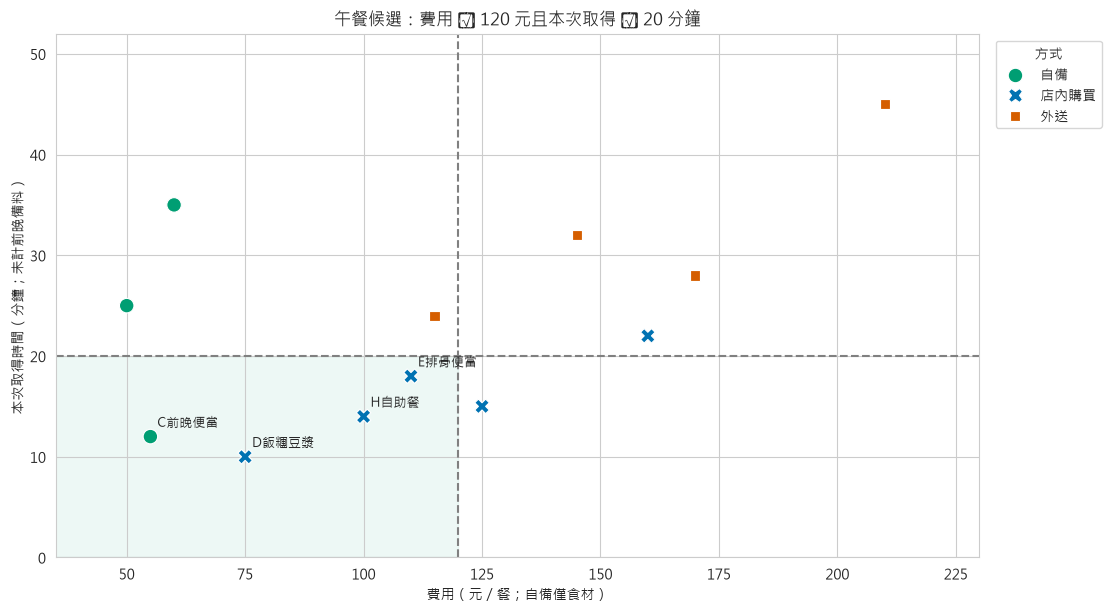

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {"自備": "#009E73", "店內購買": "#0072B2", "外送": "#D55E00"}

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
	sns.scatterplot(data=df, x="費用", y="取得分鐘", hue="方式", style="方式", palette=palette,
					hue_order=["自備", "店內購買", "外送"], style_order=["自備", "店內購買", "外送"], s=110, ax=ax)
	ax.axvline(budget, color="gray", linestyle="--")
	ax.axhline(time_limit, color="gray", linestyle="--")
	ax.fill_between([0, budget], 0, time_limit, color="#009E73", alpha=0.07, zorder=0)
	candidates = df.loc[df["符合條件"]].sort_values(["費用", "取得分鐘"])
	for _, row in candidates.iterrows():
		ax.annotate(row["選項"], (row["費用"], row["取得分鐘"]), xytext=(5, 7), textcoords="offset points", fontsize=9)
	ax.set(title="午餐候選：費用 ≤ 120 元且本次取得 ≤ 20 分鐘", xlabel="費用（元／餐；自備僅食材）",
		ylabel="本次取得時間（分鐘；未計前晚備料）", xlim=(35, 230), ylim=(0, 52))
	sns.move_legend(ax, "upper left", bbox_to_anchor=(1.01, 1), title="方式")
	plt.show()